# Neural Multimodal Classifier

## Introduction

This notebook builds a neural network model for binary image-text matching.

[Previous baseline experiments](https://github.com/Maxstef/flickr30k-multimodal-retrieval/blob/main/notebooks/03_baseline_models.ipynb) showed that text-only and linear multimodal models are not sufficient for this task, while a non-linear MLP can learn some useful relationships between image and text features.

In this notebook, the model is implemented in PyTorch and trained using image-caption pairs prepared earlier in the project.

The main experiments are:

1. Train a neural multimodal classifier with a frozen ResNet18 image encoder.
2. Fine-tune the last ResNet18 block and compare the results.

This allows us to evaluate whether adapting the visual encoder to the Flickr30k image-text matching task improves performance.

## Setup & Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import torch

from src.config import (
    DATASET_NAME,
    RANDOM_SEED,
    DEVICE,
)

from src.data.loaders import load_flickr30k_splits
from src.data.preparation import prepare_binary_dataset

## Loading and Preparing the Dataset

The same binary image-text matching dataset preparation pipeline from previous notebooks is reused here. Positive and negative image-caption pairs are generated separately for each split to avoid data leakage.

In [6]:
train_data, val_data, test_data = load_flickr30k_splits(DATASET_NAME)

train_pairs = prepare_binary_dataset(train_data, seed=RANDOM_SEED)
val_pairs = prepare_binary_dataset(val_data, seed=RANDOM_SEED)

train_pairs.shape, val_pairs.shape

((290000, 4), (10140, 4))

## Text Vocabulary and Tokenization

Unlike the TF-IDF baseline, the neural model will learn trainable word embeddings. To do this, captions need to be converted from raw text into sequences of integer token IDs.

A vocabulary is built using only the training captions to avoid data leakage. Special tokens are added for padding and unknown words.

In [24]:
from src.text.tokenization import build_vocab, encode_caption
from src.config import (
    VOCAB_MIN_FREQUENCY,
    MAX_CAPTION_LENGTH,
    EMBEDDING_DIM,
)

In [25]:
VOCAB_MIN_FREQUENCY, MAX_CAPTION_LENGTH, EMBEDDING_DIM

(1, 32, 128)

In [26]:
vocab = build_vocab(
    train_pairs["caption"],
    min_freq=VOCAB_MIN_FREQUENCY,
)

len(vocab)

17714

In [27]:
sample_caption1 = train_pairs["caption"].iloc[20000]
sample_caption2 = train_pairs["caption"].iloc[1442]

print(sample_caption1)
print(encode_caption(sample_caption1, vocab, max_length=32))
print('\n')
print(sample_caption2)
print(encode_caption(sample_caption2, vocab, max_length=32))

Five people in a gym.
[1466, 62, 9, 2, 739, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


A man standing with his eyes downcast.
[2, 28, 182, 43, 191, 1872, 2422, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### Vocabulary Construction

A vocabulary is built using only the training captions to avoid data leakage. Each unique word is assigned a unique integer identifier, which serves as an index into a trainable embedding layer.

Unlike the TF-IDF representation used in [the previous notebook](https://github.com/Maxstef/flickr30k-multimodal-retrieval/blob/main/notebooks/03_baseline_models.ipynb), these integer IDs do not carry semantic meaning themselves. Instead, the neural network learns dense vector representations (embeddings) for each word during training. Since the Flickr30k vocabulary contains only about 17,700 unique words, all tokens are retained (`min_freq=1`), allowing the model to learn representations even for infrequent but potentially informative words.


### Caption Encoding

Each caption is tokenized and converted into a sequence of integer token IDs. Since neural networks require inputs of equal length within a batch, all captions are padded or truncated to a fixed length of **32 tokens**.

This value was selected based on [the exploratory data analysis](https://github.com/Maxstef/flickr30k-multimodal-retrieval/blob/main/notebooks/01_eda.ipynb), which showed that most Flickr30k captions contain fewer than 20 words, while only a small number exceed 32 words. As a result, nearly all captions are preserved in full while keeping the input representation compact and computationally efficient.


## PyTorch Dataset

To efficiently train the neural network, the image-caption pairs are wrapped in a custom PyTorch `Dataset`. Each sample consists of an image, an encoded caption, and the corresponding binary label. The dataset is then used together with a `DataLoader` to create mini-batches during training.

### PyTorch Dataset Design

The project implements two custom PyTorch datasets to support different training scenarios.

For experiments with a **frozen ResNet18 encoder**, precomputed image embeddings are used instead of raw images. Since the visual encoder is not updated during training, the image features can be extracted once and reused across all epochs, significantly reducing training time.

For **fine-tuning experiments**, raw images are retrieved from the Hugging Face dataset on demand and transformed inside `__getitem__()`. This approach avoids duplicating image data, keeps memory usage low, and allows image augmentations and the image encoder to be updated during training.

Using separate datasets provides an efficient implementation for the frozen encoder while preserving the flexibility required for end-to-end fine-tuning.


### Raw-Image Dataset

In [28]:
from src.datasets.multimodal_dataset import Flickr30kBinaryDataset
from src.features.image_features import get_resnet18_transforms
from src.config import MAX_CAPTION_LENGTH

In [29]:
image_transform = get_resnet18_transforms()

train_dataset = Flickr30kBinaryDataset(
    pairs=train_pairs,
    hf_dataset=train_data,
    vocab=vocab,
    transform=image_transform,
    max_length=MAX_CAPTION_LENGTH,
)

val_dataset = Flickr30kBinaryDataset(
    pairs=val_pairs,
    hf_dataset=val_data,
    vocab=vocab,
    transform=image_transform,
    max_length=MAX_CAPTION_LENGTH,
)

len(train_dataset), len(val_dataset)

(290000, 10140)

In [ ]:
# 0 - [image, caption, label]; 00 - 3 colors; 000 - red color channel; 01 - caption, 02 - label (1 or 0)
len(train_dataset[0]), len(train_dataset[0][0]), len(train_dataset[0][0][0]), len(train_dataset[0][1]), train_dataset[0][2].shape

(3, 3, 224, 32, torch.Size([]))

In [50]:
image, caption, label = train_dataset[0]

image.shape, caption.shape, label

(torch.Size([3, 224, 224]), torch.Size([32]), tensor(0.))

### Raw-Image Dataset Verification

A sample retrieved from the raw-image dataset confirms that the preprocessing pipeline works as expected. Each item consists of a transformed image tensor, an encoded caption represented as a fixed-length sequence of token IDs, and the corresponding binary label.

This dataset will be useful for the later fine-tuning experiment, where images must be passed through the ResNet18 encoder during training.


In [66]:
# sanity check - inspect random sample
sample_index = 100
image, caption, label = train_dataset[sample_index]

print(image.shape)
print(caption)
print(label)

torch.Size([3, 224, 224])
tensor([  2,  28,  30, 484,   9, 116,  22,   2, 134,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0])
tensor(1.)


Caption:
A man is jogging in front of a wall.

Encoded:
[2, 28, 30, 484, 9, 116, 22, 2, 134, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Label: 1.0


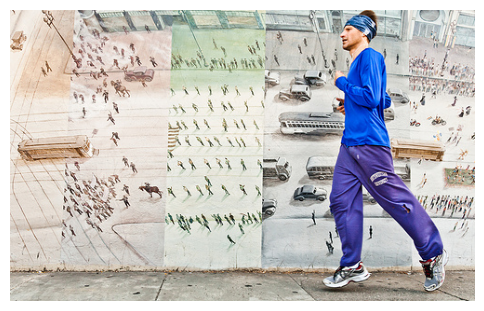

In [67]:
import matplotlib.pyplot as plt

sample = train_pairs.iloc[sample_index]

image_idx = train_dataset.filename_to_index[sample["filename"]]
image = train_data[image_idx]["image"]

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")

print("Caption:")
print(sample["caption"])
print("\nEncoded:")
print(caption.tolist())
print("\nLabel:", label.item())


## DataLoaders

The custom PyTorch datasets are wrapped in `DataLoader` objects to create mini-batches for training and validation.

Mini-batching allows the model to process multiple image-caption pairs at once, which makes training more efficient and enables gradient-based optimization.

In [68]:
from torch.utils.data import DataLoader
from src.config import BATCH_SIZE

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

len(train_loader), len(val_loader)

(9063, 317)

In [70]:
# sanity check
len(train_dataset) / BATCH_SIZE

9062.5

In [71]:
# Verify one batch
images, captions, labels = next(iter(train_loader))

images.shape, captions.shape, labels.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32, 32]), torch.Size([32]))

ResNet18_Weights.DEFAULT resize image to 224x224

### Observation

The DataLoader successfully creates batches of image-caption pairs. Each batch contains image tensors, encoded caption tensors, and binary labels. These batches are now ready to be passed into the neural multimodal classifier.

## Input Pipeline Overview

At this stage, the complete data preprocessing pipeline has been implemented. Starting from the original Flickr30k dataset, image-caption pairs are transformed into mini-batches that can be directly consumed by a neural network.

The processing pipeline consists of the following steps:

1. Generate positive and negative image-caption pairs.
2. Build a vocabulary from the training captions.
3. Tokenize and encode captions into fixed-length sequences of token IDs.
4. Create a custom PyTorch `Dataset` that retrieves images on demand and returns image, caption, and label tensors.
5. Wrap the dataset with `DataLoader` objects to produce shuffled mini-batches during training.

The resulting batches contain image tensors, encoded caption tensors, and binary labels, providing the complete input required by the neural multimodal classifier.


In [72]:
images, captions, labels = next(iter(train_loader))

print(f"Images:   {images.shape}")
print(f"Captions: {captions.shape}")
print(f"Labels:   {labels.shape}")

Images:   torch.Size([32, 3, 224, 224])
Captions: torch.Size([32, 32])
Labels:   torch.Size([32])


## Frozen ResNet18 Experiment

The first experiment uses a pretrained **ResNet18** image encoder with frozen weights. Since the visual encoder is not updated during training, image features can be extracted once and reused throughout all training epochs.

This significantly reduces the computational cost by avoiding repeated forward passes through the CNN, allowing the experiment to focus on learning the text embeddings and multimodal classifier. The raw-image dataset and training pipeline developed earlier are preserved and will be reused in the next experiment, where the image encoder is fine-tuned end-to-end.


### Image Feature Extraction

For the frozen ResNet18 experiment, image embeddings are extracted once before training. Since the ResNet18 encoder is not updated during this experiment, the same 512-dimensional image features can be reused across all epochs.

This avoids repeatedly passing the same images through the CNN during every training epoch and significantly reduces training time.

In [92]:
from src.features.image_features import (
    get_resnet18_feature_extractor,
    get_resnet18_transforms,
    extract_image_features,
)

image_feature_extractor = get_resnet18_feature_extractor(DEVICE)
image_transform = get_resnet18_transforms()

train_image_features = extract_image_features(
    train_data,
    image_feature_extractor,
    image_transform,
    DEVICE,
)

val_image_features = extract_image_features(
    val_data,
    image_feature_extractor,
    image_transform,
    DEVICE,
)

100%|██████████| 1014/1014 [00:12<00:00, 81.23it/s]


In [93]:
len(train_image_features), len(val_image_features)

(29000, 1014)

In [94]:
# Check one embedding
sample_filename = train_data["filename"][0]

train_image_features[sample_filename].shape

torch.Size([512])

### Embedding Dataset

After extracting image features, a second custom PyTorch dataset is created for the frozen ResNet18 experiment. Instead of returning raw images, this dataset retrieves the precomputed 512-dimensional image embeddings together with the encoded captions and binary labels.

Using precomputed embeddings eliminates redundant forward passes through the frozen image encoder, significantly reducing the computational cost of training while preserving the same visual representations.


In [95]:
from src.datasets.embedding_dataset import Flickr30kEmbeddingDataset

train_embedding_dataset = Flickr30kEmbeddingDataset(
    pairs=train_pairs,
    image_features=train_image_features,
    vocab=vocab,
    max_length=MAX_CAPTION_LENGTH,
)

val_embedding_dataset = Flickr30kEmbeddingDataset(
    pairs=val_pairs,
    image_features=val_image_features,
    vocab=vocab,
    max_length=MAX_CAPTION_LENGTH,
)

len(train_embedding_dataset), len(val_embedding_dataset)

(290000, 10140)

In [98]:
image_embedding, caption, label = train_embedding_dataset[0]

print("Image embedding:", image_embedding.shape)
print("Caption:", caption.shape)
print("Label:", label)

Image embedding: torch.Size([512])
Caption: torch.Size([32])
Label: tensor(0.)


### Embedding Dataset Verification

A sample retrieved from the embedding dataset confirms that each training example consists of a precomputed image embedding, an encoded caption, and the corresponding binary label. These representations provide all the information required for training the frozen ResNet18 model without repeatedly processing raw images.


### Embedding DataLoader

The embedding datasets are wrapped in PyTorch `DataLoader` objects to create mini-batches for training and validation.

Each batch now contains precomputed image embeddings instead of raw images, allowing the model to focus on learning the text representations and multimodal classifier while avoiding repeated image feature extraction.


In [99]:
from torch.utils.data import DataLoader

train_embedding_loader = DataLoader(
    train_embedding_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_embedding_loader = DataLoader(
    val_embedding_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [100]:
len(train_embedding_loader), len(val_embedding_loader)

(9063, 317)

In [ ]:
len(train_embedding_dataset) / BATCH_SIZE

9062.5

In [ ]:
# Verify one batch
image_embeddings, captions, labels = next(iter(train_embedding_loader))

print("Image embeddings:", image_embeddings.shape)
print("Captions:", captions.shape)
print("Labels:", labels.shape)

Image embeddings: torch.Size([32, 512])
Captions: torch.Size([32, 32])
Labels: torch.Size([32])


#### Observation

The embedding DataLoader successfully creates mini-batches containing precomputed image embeddings, encoded captions, and binary labels. These batches are ready to be passed directly to the frozen multimodal classifier without performing additional image feature extraction during training.


### Neural Multimodal Embedding Classifier

For the frozen ResNet18 experiment, the model receives precomputed image embeddings instead of raw images. The text branch remains trainable: caption token IDs are passed through an embedding layer and averaged to produce a caption representation.

The image and text representations are concatenated and passed through a feed-forward classifier to predict whether the image-caption pair is a match.

In [123]:
from src.models.multimodal_embedding_classifier import NeuralMultimodalEmbeddingClassifier

embedding_model = NeuralMultimodalEmbeddingClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    image_feature_dim=IMAGE_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
).to(DEVICE)

embedding_model

NeuralMultimodalEmbeddingClassifier(
  (text_embedding): Embedding(17714, 128, padding_idx=0)
  (classifier): Sequential(
    (0): Linear(in_features=640, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [124]:
# Forward-pass check
image_embeddings, captions, labels = next(iter(train_embedding_loader))

image_embeddings = image_embeddings.to(DEVICE)
captions = captions.to(DEVICE)

outputs = embedding_model(image_embeddings, captions)

outputs.shape

torch.Size([32])

### Loss Function and Optimizer

The frozen ResNet18 experiment is trained as a binary classification task. The model outputs raw logits, so `BCEWithLogitsLoss` is used because it combines a sigmoid activation with binary cross-entropy in a numerically stable way.

Adam is used as the optimizer to update the trainable text embedding layer and classifier parameters.

In [125]:
loss_fn = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    params=embedding_model.parameters(),
    lr=LEARNING_RATE,
)

In [126]:
# trainable parameters
total_params = sum(p.numel() for p in embedding_model.parameters())
trainable_params = sum(
    p.numel()
    for p in embedding_model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 2,448,001
Trainable parameters: 2,448,001


### Training Configuration

The model is trained for a fixed number of epochs using mini-batches from the embedding DataLoader. Since image features are precomputed, training is expected to be much faster than passing raw images through ResNet18 during every epoch.

Validation performance is monitored after each epoch using F1-score as the main metric.

In [127]:
from src.config import RESULTS_DIR, MODELS_DIR

# init history
history = []

print(f"Device: {DEVICE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")

Device: mps
Epochs: 10
Batch size: 32
Learning rate: 0.001


### Training Loop

In [128]:
from timeit import default_timer as timer
import torch

best_val_f1 = 0
best_epoch = 0

history = []

train_start = timer()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(
        model=embedding_model,
        dataloader=train_embedding_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=DEVICE,
    )

    val_metrics = evaluate(
        model=embedding_model,
        dataloader=val_embedding_loader,
        loss_fn=loss_fn,
        device=DEVICE,
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
    }

    history.append(epoch_results)

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1

        torch.save(
            embedding_model.state_dict(),
            MODELS_DIR / "frozen_resnet18_embedding_classifier.pt",
        )

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

train_end = timer()

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Training time: {train_end - train_start:.1f} seconds")


Epoch 1/10


Evaluating: 100%|██████████| 317/317 [00:00<00:00, 324.52it/s]


Train loss: 0.6931 | Val loss: 0.6804 | Val F1: 0.6316

Epoch 2/10


Evaluating: 100%|██████████| 317/317 [00:01<00:00, 316.64it/s]


Train loss: 0.6006 | Val loss: 0.5641 | Val F1: 0.7385

Epoch 3/10


...

Train loss: 0.4897 | Val loss: 0.5234 | Val F1: 0.7863

Epoch 9/10


Evaluating: 100%|██████████| 317/317 [00:01<00:00, 284.29it/s]


Train loss: 0.4837 | Val loss: 0.5236 | Val F1: 0.7846

Epoch 10/10


Evaluating: 100%|██████████| 317/317 [00:00<00:00, 326.19it/s]


Train loss: 0.4802 | Val loss: 0.5420 | Val F1: 0.7789

Best epoch: 8
Best validation F1: 0.7863
Training time: 668.5 seconds


### Results & Save

In [129]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    RESULTS_DIR / "frozen_resnet18_training_history.csv",
    index=False,
)

history_df

,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,1,0.693097,0.680432,0.533235,0.521661,0.800394,0.631644
1,2,0.600596,0.564149,0.701183,0.656538,0.843787,0.738477
2,3,0.557716,0.530100,0.737475,0.685802,0.876529,0.769524
3,4,0.531792,0.518790,0.744083,0.689655,0.887574,0.776197
4,5,0.514466,0.521036,0.740335,0.671838,0.939645,0.783488
5,6,0.503160,0.520806,0.739448,0.670986,0.939645,0.782909
6,7,0.495519,0.544929,0.721893,0.649086,0.966075,0.776474
7,8,0.489677,0.523448,0.739842,0.667171,0.957199,0.786293
8,9,0.483686,0.523628,0.737968,0.666070,0.954438,0.784597
9,10,0.480212,0.541985,0.725049,0.651366,0.968442,0.778871


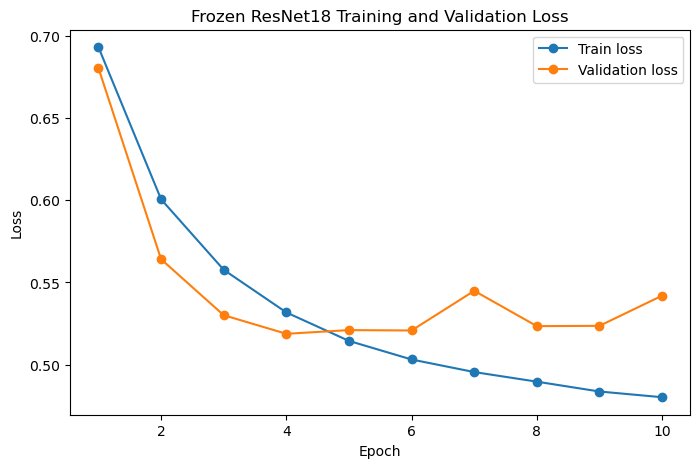

In [130]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")

plt.title("Frozen ResNet18 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [131]:
best_row = history_df.loc[history_df["val_f1"].idxmax()]

frozen_resnet18_metrics = pd.DataFrame(
    [
        {
            "model": "Frozen ResNet18 Neural Classifier",
            "split": "validation",
            "accuracy": best_row["val_accuracy"],
            "precision": best_row["val_precision"],
            "recall": best_row["val_recall"],
            "f1": best_row["val_f1"],
            "best_epoch": int(best_row["epoch"]),
            "training_time_seconds": train_end - train_start,
        }
    ]
)

frozen_resnet18_metrics.to_csv(
    RESULTS_DIR / "frozen_resnet18_metrics.csv",
    index=False,
)

frozen_resnet18_metrics

,model,split,accuracy,precision,recall,f1,best_epoch,training_time_seconds
0,Frozen ResNet18 Neural Classifier,validation,0.739842,0.667171,0.957199,0.786293,8,668.476075


In [115]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,1,0.679019,0.603684,0.655917,0.602943,0.913215,0.726331
1,2,0.595426,0.553701,0.713609,0.658195,0.888757,0.756294
2,3,0.566961,0.535532,0.730868,0.670701,0.907101,0.771191
3,4,0.547963,0.513967,0.753254,0.694900,0.902959,0.785383
4,5,0.533248,0.540397,0.718935,0.650284,0.947337,0.771195
5,6,0.515987,0.582146,0.685503,0.615954,0.985404,0.758061
6,7,0.508023,0.561718,0.700789,0.629155,0.978107,0.765750
7,8,0.501979,0.586905,0.690828,0.620802,0.980671,0.760303
8,9,0.496688,0.594618,0.689744,0.619355,0.984615,0.760396
9,10,0.492721,0.572535,0.697633,0.628002,0.969625,0.762289


### Observation

The frozen ResNet18 neural classifier successfully learns meaningful multimodal representations, with both training and validation performance improving steadily during the first training epochs. The decreasing training loss and increasing validation metrics indicate that the model effectively combines pretrained visual features with trainable text embeddings to distinguish matching and non-matching image-caption pairs.

While the training loss continues to decrease throughout training, the validation loss and F1-score begin to stabilize in later epochs, suggesting that the model is approaching its optimal performance and that additional training provides only limited improvements. Overall, the model demonstrates a substantial improvement over the previously implemented classical baselines while maintaining efficient training through the use of precomputed image embeddings.

The best-performing model checkpoint, training history, and evaluation metrics were saved for later comparison with the fine-tuning experiment.


## Neural Multimodal Classifier (Draft)

The neural multimodal classifier receives two inputs: an image tensor and an encoded caption tensor.

The image branch uses a pretrained ResNet18 model as a visual encoder. The final classification layer is removed, so the network outputs a 512-dimensional image representation.

The text branch uses a trainable embedding layer to convert caption token IDs into dense word vectors. These word vectors are averaged across the caption length to produce a single text representation.

The image and text representations are concatenated and passed through a small feed-forward classifier to predict whether the image and caption match.

In [73]:
from src.models.multimodal_classifier import NeuralMultimodalClassifier

from src.config import (
    EMBEDDING_DIM,
    IMAGE_FEATURE_DIM,
    HIDDEN_DIM,
    DROPOUT,
)

In [76]:
model = NeuralMultimodalClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    image_feature_dim=IMAGE_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    freeze_image_encoder=True,
).to(DEVICE)

model

NeuralMultimodalClassifier(
  (image_encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.

In [82]:
# test one forward pass
images, captions, labels = next(iter(train_loader))

images = images.to(DEVICE)
captions = captions.to(DEVICE)

outputs = model(images, captions)

outputs.shape

torch.Size([32])

## Model Training (Draft)

With the data pipeline and neural network architecture in place, the model is ready to be trained.

The training objective is to learn whether a given image-caption pair is a correct match. During each iteration, batches of images and encoded captions are passed through the network, the prediction error is computed using a binary classification loss, and the model parameters are updated using gradient-based optimization.

The training process is implemented using reusable utility functions for one training epoch and model evaluation, keeping the notebook focused on the experimental workflow while making the training code reusable for future models.


### Training loop diagram

Batch from DataLoader

        │
        ▼
NeuralMultimodalClassifier

        │
        ▼
Prediction logits

        │
        ▼
BCEWithLogitsLoss

        │
        ▼
Backpropagation

        │
        ▼
Optimizer step

### Loss Function and Optimizer

Since this is a binary classification task, the model is trained using `BCEWithLogitsLoss`. The model outputs raw logits, and the loss function internally applies the sigmoid operation before computing binary cross-entropy.

For optimization, Adam is used because it is a strong general-purpose optimizer for neural networks and usually works well as a first choice.

In [84]:
import torch
from src.config import LEARNING_RATE

loss_fn = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=LEARNING_RATE,
)

### Trainable Parameters

Before training, the number of trainable parameters is inspected to verify which parts of the model will be updated. In this first experiment, the pretrained ResNet18 image encoder is frozen, so only the text embedding layer and the multimodal classifier are optimized during training.


In [85]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 13,624,513
Trainable parameters: 2,448,001


#### Observation

The model contains approximately **13.6 million parameters**, of which **2.45 million are trainable**. Since the ResNet18 image encoder is frozen, only the text embedding layer and the multimodal classifier are optimized during training. This transfer learning strategy significantly reduces the number of parameters that need to be updated while still allowing the model to learn task-specific multimodal representations.


### Training Configuration

The model is trained for a fixed number of epochs using mini-batches from the training DataLoader. After each epoch, performance is evaluated on the validation set.

The main metric used for model comparison is F1-score, since it balances precision and recall and is more informative than accuracy alone for evaluating positive image-caption matches.

In [87]:
from src.config import NUM_EPOCHS

# init history
history = []

print(f"Device: {DEVICE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")

Device: mps
Epochs: 10
Batch size: 32
Learning rate: 0.001


### Training Loop

The model is trained for several epochs. After each epoch, the validation set is evaluated to monitor generalization performance.

In [88]:
from src.training.engine import train_one_epoch, evaluate

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=DEVICE,
    )

    val_metrics = evaluate(
        model=model,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=DEVICE,
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
    }

    history.append(epoch_results)

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

Epoch 1/10


Training:  28%|██▊       | 2523/9063 [08:04<20:54,  5.21it/s] 


KeyboardInterrupt: 

In [ ]:
history_df = pd.DataFrame(history)
history_df

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["val_f1"], marker="o")

plt.title("Validation F1-score During Training")
plt.xlabel("Epoch")
plt.ylabel("F1-score")

plt.show()